Labsheet - 04
Name - Ujjawal chauhan 
roll no - 62 "B"
cu24250259

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [24]:
img=cv2.imread("cameraman.png",cv2.IMREAD_GRAYSCALE)
print("Image loaded successfully")
print("Image size:",img.shape)

Image loaded successfully
Image size: (256, 256)


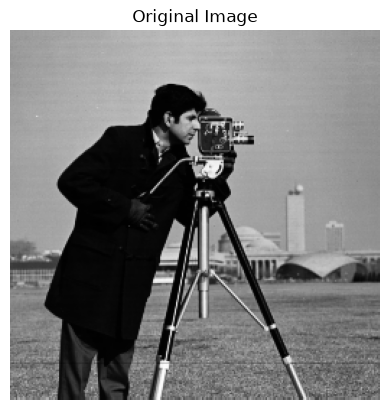

In [25]:
plt.imshow(img,cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

In [26]:
dft=cv2.dft(np.float32(img),flags=cv2.DFT_COMPLEX_OUTPUT)
print("DFT computed successfully")

DFT computed successfully


In [27]:
dft_shift=np.fft.fftshift(dft)
print("Zero frequency shifted to center")

Zero frequency shifted to center


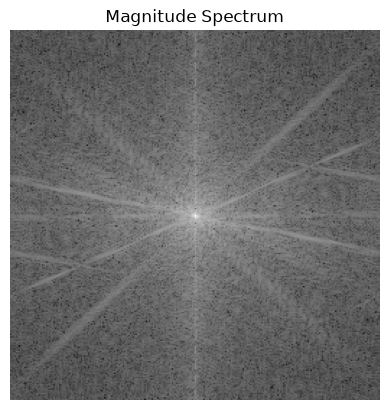

In [28]:
magnitude=np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1])+1)

plt.imshow(magnitude,cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")
plt.show()

In [29]:
rows,cols=img.shape
crow,ccol=rows//2,cols//2
mask_low=np.zeros((rows,cols,2),np.uint8)
r=50
cv2.circle(mask_low,(ccol,crow),r,(1,1),-1)

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], shape=(256, 256, 2), dtype=uint8)

In [30]:
low_pass=dft_shift*mask_low

In [31]:
low_shift=np.fft.ifftshift(low_pass)
low_img=cv2.idft(low_shift)
low_img=cv2.magnitude(low_img[:,:,0],low_img[:,:,1])

low_img=cv2.normalize(low_img,None,0,255,cv2.NORM_MINMAX)
low_img=np.uint8(low_img)

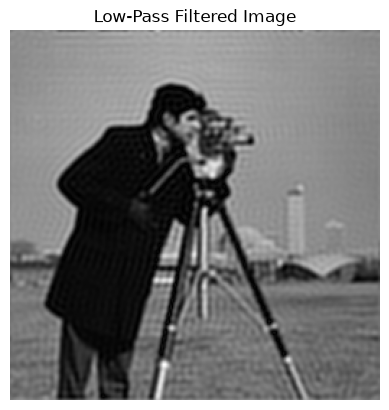

In [32]:
plt.imshow(low_img,cmap="gray")
plt.title("Low-Pass Filtered Image")
plt.axis("off")
plt.show()

In [33]:
mask_high=np.ones((rows,cols,2),np.uint8)
cv2.circle(mask_high,(ccol,crow),r,(0,0),-1)

array([[[1, 1],
        [1, 1],
        [1, 1],
        ...,
        [1, 1],
        [1, 1],
        [1, 1]],

       [[1, 1],
        [1, 1],
        [1, 1],
        ...,
        [1, 1],
        [1, 1],
        [1, 1]],

       [[1, 1],
        [1, 1],
        [1, 1],
        ...,
        [1, 1],
        [1, 1],
        [1, 1]],

       ...,

       [[1, 1],
        [1, 1],
        [1, 1],
        ...,
        [1, 1],
        [1, 1],
        [1, 1]],

       [[1, 1],
        [1, 1],
        [1, 1],
        ...,
        [1, 1],
        [1, 1],
        [1, 1]],

       [[1, 1],
        [1, 1],
        [1, 1],
        ...,
        [1, 1],
        [1, 1],
        [1, 1]]], shape=(256, 256, 2), dtype=uint8)

In [34]:
high_pass=dft_shift*mask_high

In [35]:
high_shift=np.fft.ifftshift(high_pass)
high_img=cv2.idft(high_shift)
high_img=cv2.magnitude(high_img[:,:,0],high_img[:,:,1])

high_img=cv2.normalize(high_img,None,0,255,cv2.NORM_MINMAX)
high_img=np.uint8(high_img)

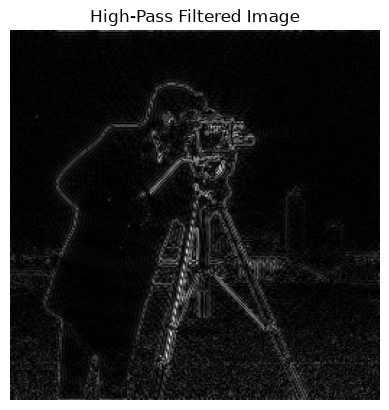

In [36]:
plt.imshow(high_img,cmap="gray")
plt.title("High-Pass Filtered Image")
plt.axis("off")
plt.show()

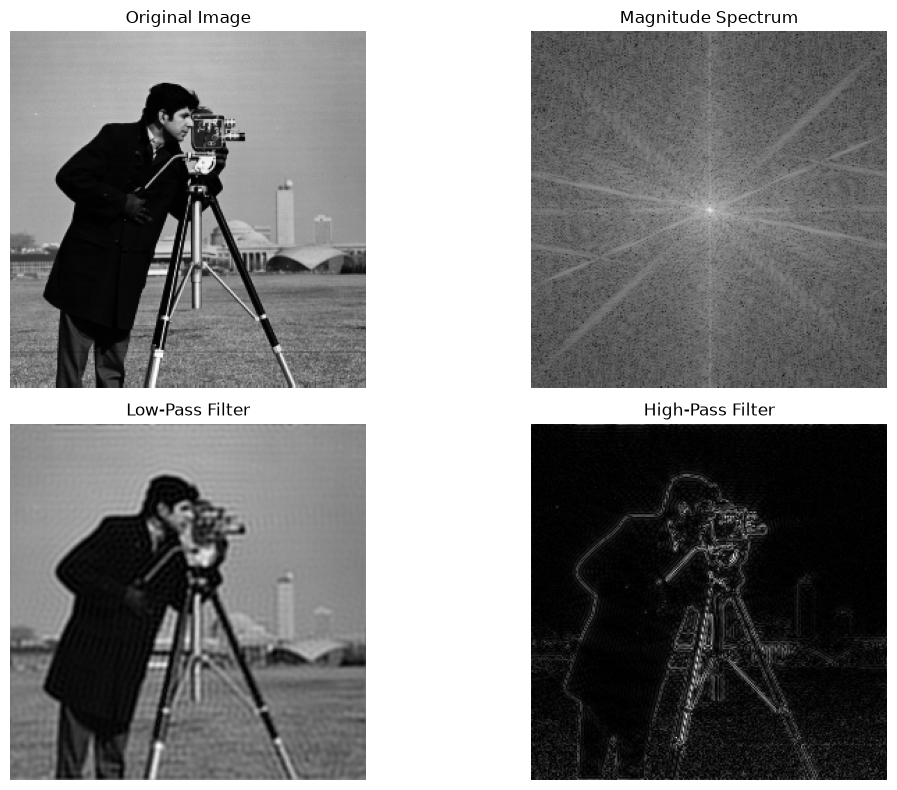

In [37]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img,cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(magnitude,cmap="gray")
plt.title("Magnitude Spectrum")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(low_img,cmap="gray")
plt.title("Low-Pass Filter")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(high_img,cmap="gray")
plt.title("High-Pass Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
print("Low-Pass Filter: Removes high-frequency components and smooths the image.")
print("High-Pass Filter: Removes low-frequency components and enhances edges.")
print("Magnitude Spectrum: Shows the frequency components of the image.")
print("DFT converts the image from spatial domain to frequency domain.")
print("IDFT reconstructs the filtered image back into the spatial domain.")

Low-Pass Filter: Removes high-frequency components and smooths the image.
High-Pass Filter: Removes low-frequency components and enhances edges.
Magnitude Spectrum: Shows the frequency components of the image.
DFT converts the image from spatial domain to frequency domain.
IDFT reconstructs the filtered image back into the spatial domain.
